In [6]:
from pyrpl import Pyrpl
from time import sleep
import finesse
import numpy as np
import matplotlib.pyplot as plt
from finesse.analysis.actions import Xaxis
import types

finesse.init_plotting()


HOSTNAME = "qifo-pitaya.local"
PASSWORD = "ligobears"

#p = Pyrpl(config='', hostname=HOSTNAME, password=PASSWORD, gui=False)
#rp = p.rp




In [7]:
c = 299792458
red_wavelength = 1064e-9
red_frequency = c / red_wavelength
green_wavelength = 532e-9
green_frequency = c / green_wavelength

n_crystal_red = 1.8302 #index of KTP crystal at 1064 nm
n_crystal_green = 1.8894 #index of KTP crystal at 532 nm



In [8]:
""" BOWTIE MODEL
#Top left: M1, Top right: M2, Bottom left curved: M3, Bottom right curved: M4
M1_transmittance = 0.15
M2_transmittance = 0.0026

katie_example_params = dict(
    L_x = 20e-3,
    theta = 5,#7
    d_1 = 25.81e-3,#61.90e-3
    d_2 = 10.95e-3,#55.68e-3
    d_3 = 40.47e-3,#(d_1 + d_2) / (2 * np.cos(np.deg2rad(theta)))
    R_c = 25e-3#46.01e-3
)

#Params for potential Berkeley squeezer setups
prototype_params = dict(
    L_x = 20e-3
)


LIGO_VOPO2_wedgeless_params = dict(
    theta = 6,
    L_x = 10.505e-3, #Averaging out wedge length
    d_1 = 59.363e-3,
    d_2 = 110.000e-3,
    d_3 = 86.573e-3,
    R_c = 50e-3,
)

#Set model parameters using SimpleNamespace bc I just like the dot notation more than indexing with dicts
params = types.SimpleNamespace(katie_example_params)
"""

' BOWTIE MODEL\n#Top left: M1, Top right: M2, Bottom left curved: M3, Bottom right curved: M4\nM1_transmittance = 0.15\nM2_transmittance = 0.0026\n\nkatie_example_params = dict(\n    L_x = 20e-3,\n    theta = 5,#7\n    d_1 = 25.81e-3,#61.90e-3\n    d_2 = 10.95e-3,#55.68e-3\n    d_3 = 40.47e-3,#(d_1 + d_2) / (2 * np.cos(np.deg2rad(theta)))\n    R_c = 25e-3#46.01e-3\n)\n\n#Params for potential Berkeley squeezer setups\nprototype_params = dict(\n    L_x = 20e-3\n)\n\n\nLIGO_VOPO2_wedgeless_params = dict(\n    theta = 6,\n    L_x = 10.505e-3, #Averaging out wedge length\n    d_1 = 59.363e-3,\n    d_2 = 110.000e-3,\n    d_3 = 86.573e-3,\n    R_c = 50e-3,\n)\n\n#Set model parameters using SimpleNamespace bc I just like the dot notation more than indexing with dicts\nparams = types.SimpleNamespace(katie_example_params)\n'

In [9]:
tunable_fc_params = dict(
    laser_power = 1, #532 nm laser power in watts
    L_x = 30e-2,
    T_M1 = 0.1,
    T_M2 = 0.001,
    modulation_freq = 60e6,
    modulation_index = 1
)


params = types.SimpleNamespace(tunable_fc_params)

model = finesse.Model()
model.parse(
    f"""
    laser l1 P={params.laser_power} f={green_frequency}
    space s1 portA=l1.p1 portB=eom1.p1
    modulator eom1 f={params.modulation_freq} midx={params.modulation_index} mod_type=pm order=3 #Just copying order param from Finesse example
    space s2 portA=eom1.p2 portB=m1.p1

    mirror m1 T={params.T_M1} L=0
    space cavity_space portA=m1.p2 portB=m2.p1 L={params.L_x}
    mirror m2 T={params.T_M2} L=0

    #Detectors
    power_detector_dc refl_pd m1.p1.o
    power_detector_dc trans_pd m2.p2.o

    pd1 demod_pd node=m1.p1.o f={params.modulation_freq} phase=18
    """
)



In [10]:
from finesse.analysis.actions import Xaxis

sol = model.run(Xaxis(model.cavity_space.L, 'lin', params.L_x, params.L_x + green_wavelength/2, 500))

#sol = model.run(Xaxis(model.m2.phi, 'lin', 0, 180, 500))



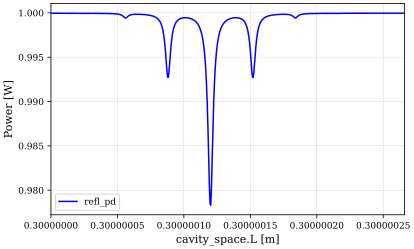

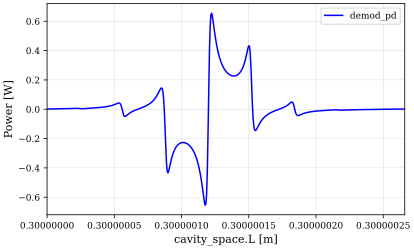

- Solution Tree
● xaxis - ArraySolution


In [11]:

sol.plot('refl_pd')

sol.plot('demod_pd')

print(sol)

#sol.plot()